# Rhombix Technologies 
# Machine Learning Internship | Month 1 | Task 1
# MINAHIL AFTAB



**Objective:** Build a music recommendation system using XGBoost that predicts whether a user will replay a song within a month.

**Dataset:** KKBOX Music Recommendation Challenge (Kaggle)

**Algorithm:** XGBoost Classifier

## 1. Installing & Import Libraries

In [44]:
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\kingm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [45]:
pip install xgboost --timeout 1000

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\kingm\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

print(" All libraries imported successfully!")

 All libraries imported successfully!


## 2.Loading Dataset

In [ ]:
train   = pd.read_csv('train.csv')
songs   = pd.read_csv('songs.csv')
members = pd.read_csv('members.csv')

print(f'   Train shape   : {train.shape}')
print(f'   Songs shape   : {songs.shape}')
print(f'   Members shape : {members.shape}')

   Train shape   : (7377418, 6)
   Songs shape   : (2296320, 7)
   Members shape : (34403, 7)


## 3. Exploring Data (EDA)

In [48]:
print(' Training Data — First 5 rows:')
train.head()

 Training Data — First 5 rows:


,msno,song_id,source_system_tab,source_screen_name,source_type,target
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,Local playlist more,local-playlist,1
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,Explore,online-playlist,1


## Printing first five rows

In [49]:
print(' Songs Data — First 5 rows:')
songs.head()

 Songs Data — First 5 rows:


,song_id,song_length,genre_ids,artist_name,composer,lyricist,language
0,CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=,247640,465,張信哲 (Jeff Chang),董貞,何啟弘,3.0
1,o0kFgae9QtnYgRkVPqLJwa05zIhRlUjfF7O1tDw0ZDU=,197328,444,BLACKPINK,TEDDY| FUTURE BOUNCE| Bekuh BOOM,TEDDY,31.0
2,DwVvVurfpuz+XPuFvucclVQEyPqcpUkHR0ne1RQzPs0=,231781,465,SUPER JUNIOR,NaN,NaN,31.0
3,dKMBWoZyScdxSkihKG+Vf47nc18N9q4m58+b4e7dSSE=,273554,465,S.H.E,湯小康,徐世珍,3.0
4,W3bqWd3T+VeHFzHAUfARgW9AvVRaF4N5Yzm4Mr6Eo/o=,140329,726,貴族精選,Traditional,Traditional,52.0


## Members Data


In [50]:
print(' Members Data — First 5 rows:')
members.head()

 Members Data — First 5 rows:


,msno,city,bd,gender,registered_via,registration_init_time,expiration_date
0,XQxgAYj3klVKjR3oxPPXYYFp4soD4TuBghkhMTD4oTw=,1,0,NaN,7,20110820,20170920
1,UizsfmJb9mV54qE9hCYyU07Va97c0lCRLEQX3ae+ztM=,1,0,NaN,7,20150628,20170622
2,D8nEhsIOBSoE6VthTaqDX8U6lqjJ7dLdr72mOyLya2A=,1,0,NaN,4,20160411,20170712
3,mCuD+tZ1hERA/o5GPqk38e041J8ZsBaLcu7nGoIIvhI=,1,0,NaN,9,20150906,20150907
4,q4HRBfVSssAFS9iRfxWrohxuk9kCYMKjHOEagUMV6rQ=,1,0,NaN,4,20170126,20170613


## 4. Target Distribution

 Target Value Distribution:
target
1    3714656
0    3662762
Name: count, dtype: int64

   Replay Rate: 50.4%


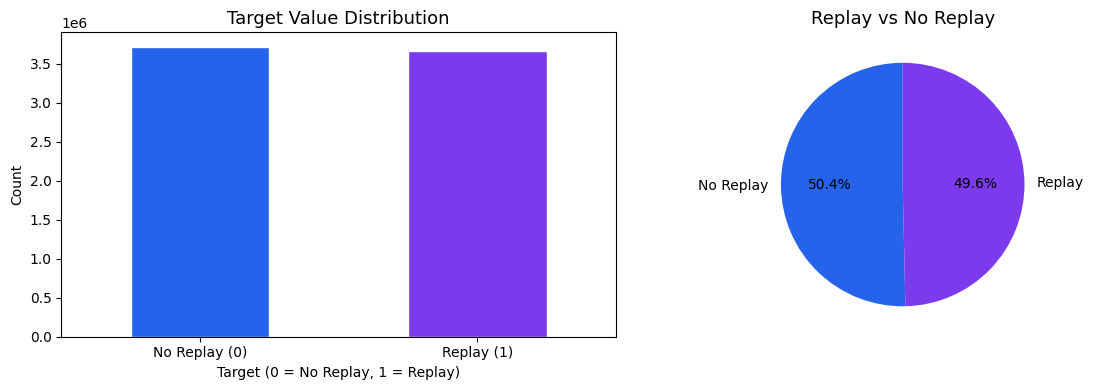

   Saved: target_distribution.png


In [51]:
print(' Target Value Distribution:')
print(train['target'].value_counts())
print(f'\n   Replay Rate: {train["target"].mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))


train['target'].value_counts().plot(kind='bar', ax=axes[0], color=['#2563eb','#7c3aed'], edgecolor='white')
axes[0].set_title('Target Value Distribution', fontsize=13)
axes[0].set_xlabel('Target (0 = No Replay, 1 = Replay)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Replay (0)', 'Replay (1)'], rotation=0)


train['target'].value_counts().plot(kind='pie', ax=axes[1],
    colors=['#2563eb','#7c3aed'], autopct='%1.1f%%',
    labels=['No Replay', 'Replay'], startangle=90)
axes[1].set_title('Replay vs No Replay', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Saved: target_distribution.png')

## 5. Identifying Missing Values

In [52]:
print(' Missing Values:')
print('\nTrain:')
print(train.isnull().sum())
print('\nSongs:')
print(songs.isnull().sum())
print('\nMembers:')
print(members.isnull().sum())

 Missing Values:

Train:
msno                       0
song_id                    0
source_system_tab      24849
source_screen_name    414804
source_type            21539
target                     0
dtype: int64

Songs:
song_id              0
song_length          0
genre_ids        94116
artist_name          0
composer       1071358
lyricist       1945306
language             1
dtype: int64

Members:
msno                          0
city                          0
bd                            0
gender                    19902
registered_via                0
registration_init_time        0
expiration_date               0
dtype: int64


## 5. Merging Datasets

In [53]:
print(' Merging train + songs + members...')

df = train.merge(songs,   on='song_id', how='left')
df = df.merge(members,    on='msno',    how='left')

print(f'   Merged DataFrame shape: {df.shape}')
print(f'   Columns: {list(df.columns)}')
df.head()

 Merging train + songs + members...
   Merged DataFrame shape: (7377418, 18)
   Columns: ['msno', 'song_id', 'source_system_tab', 'source_screen_name', 'source_type', 'target', 'song_length', 'genre_ids', 'artist_name', 'composer', 'lyricist', 'language', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time', 'expiration_date']


,msno,song_id,source_system_tab,source_screen_name,source_type,target,song_length,genre_ids,artist_name,composer,lyricist,language,city,bd,gender,registered_via,registration_init_time,expiration_date
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,Explore,online-playlist,1,206471.0,359,Bastille,Dan Smith| Mark Crew,NaN,52.0,1,0,NaN,7,20120102,20171005
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,Local playlist more,local-playlist,1,284584.0,1259,Various Artists,NaN,NaN,52.0,13,24,female,9,20110525,20170911
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,Local playlist more,local-playlist,1,225396.0,1259,Nas,N. Jones、W. Adams、J. Lordan、D. Ingle,NaN,52.0,13,24,female,9,20110525,20170911
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,Local playlist more,local-playlist,1,255512.0,1019,Soundway,Kwadwo Donkoh,NaN,-1.0,13,24,female,9,20110525,20170911
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,Explore,online-playlist,1,187802.0,1011,Brett Young,Brett Young| Kelly Archer| Justin Ebach,NaN,52.0,1,0,NaN,7,20120102,20171005


## 6. Data Cleaning

### Filling missing numeric values with median


In [54]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())




### Filling missing categorical values with 'Unknown'


In [55]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('Unknown')

### Converting song_length from ms to seconds


In [56]:
if 'song_length' in df.columns:
    df['song_length_sec'] = df['song_length'] / 1000
    print('   Converted song_length to seconds')

   Converted song_length to seconds


### Fix unrealistic ages (bd column)

In [57]:
if 'bd' in df.columns:
    df['bd'] = df['bd'].apply(lambda x: x if 1 < x < 100 else np.nan)
    df['bd'].fillna(df['bd'].median(), inplace=True)
    print('   Fixed unrealistic age values')

print(f'\n   Missing values after cleaning: {df.isnull().sum().sum()}')
print(' Data cleaning complete!')

   Fixed unrealistic age values

   Missing values after cleaning: 2947202
 Data cleaning complete!


## 7. Feature Engineering

In [58]:
print(' Engineering features...')

# 1. Song popularity — how many users played this song
song_stats = df.groupby('song_id')['target'].agg(['count', 'mean']).reset_index()
song_stats.columns = ['song_id', 'song_play_count', 'song_replay_rate']
df = df.merge(song_stats, on='song_id', how='left')
print('    Song popularity features added')

# 2. User activity — how many songs each user listens to
user_stats = df.groupby('msno')['target'].agg(['count', 'mean']).reset_index()
user_stats.columns = ['msno', 'user_play_count', 'user_replay_rate']
df = df.merge(user_stats, on='msno', how='left')
print('    User activity features added')

# 3. Artist popularity
if 'artist_name' in df.columns:
    artist_pop = df.groupby('artist_name')['target'].mean().reset_index()
    artist_pop.columns = ['artist_name', 'artist_popularity']
    df = df.merge(artist_pop, on='artist_name', how='left')
    print('    Artist popularity features added')

# 4. Source type replay rate
if 'source_type' in df.columns:
    source_stats = df.groupby('source_type')['target'].mean().reset_index()
    source_stats.columns = ['source_type', 'source_replay_rate']
    df = df.merge(source_stats, on='source_type', how='left')
    print('    Source type features added')

# 5. Genre replay rate
if 'genre_ids' in df.columns:
    genre_stats = df.groupby('genre_ids')['target'].mean().reset_index()
    genre_stats.columns = ['genre_ids', 'genre_replay_rate']
    df = df.merge(genre_stats, on='genre_ids', how='left')
    print('    Genre features added')

print(f'\n   Total features now: {df.shape[1]}')
print(' Feature engineering complete!')

 Engineering features...
    Song popularity features added
    User activity features added
    Artist popularity features added
    Source type features added
    Genre features added

   Total features now: 26
 Feature engineering complete!


## 8.Encoding Categorical Values

In [59]:
print(' Encoding categorical columns...')

le = LabelEncoder()

cat_columns = [
    'msno', 'song_id', 'source_system_tab', 'source_screen_name',
    'source_type', 'genre_ids', 'artist_name', 'composer',
    'lyricist', 'language', 'city', 'gender', 'registered_via'
]

for col in cat_columns:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
        print(f'   Encoded: {col}')

print('\n Encoding complete!')

 Encoding categorical columns...
   Encoded: msno
   Encoded: song_id
   Encoded: source_system_tab
   Encoded: source_screen_name
   Encoded: source_type
   Encoded: genre_ids
   Encoded: artist_name
   Encoded: composer
   Encoded: lyricist
   Encoded: language
   Encoded: city
   Encoded: gender
   Encoded: registered_via

 Encoding complete!


## 9.  Select Features & Target

In [60]:
print(' Selecting features and target...')

# Drop non-feature columns

drop_cols = [
    'target',
    'registration_init_time',
    'expiration_date',
    'song_length',
    'song_replay_rate',   
    'user_replay_rate',   
    'artist_popularity',  
    'genre_replay_rate',  
    'source_replay_rate', 
]
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df['target']

print(f'   Number of features : {len(feature_cols)}')
print(f'   Features           : {feature_cols}')
print(f'   Total samples      : {len(X):,}')
print(f'   Positive (Replay)  : {y.sum():,} ({y.mean()*100:.1f}%)')

 Selecting features and target...
   Number of features : 17
   Features           : ['msno', 'song_id', 'source_system_tab', 'source_screen_name', 'source_type', 'genre_ids', 'artist_name', 'composer', 'lyricist', 'language', 'city', 'bd', 'gender', 'registered_via', 'song_length_sec', 'song_play_count', 'user_play_count']
   Total samples      : 7,377,418
   Positive (Replay)  : 3,714,656 (50.4%)


## 10. Train - Test Split

In [61]:
print('Splitting data into train (80%) and test (20%)...')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y       
)

print(f'   Training samples : {len(X_train):,}')
print(f'   Testing samples  : {len(X_test):,}')
print(f'   Train replay rate: {y_train.mean()*100:.1f}%')
print(f'   Test  replay rate: {y_test.mean()*100:.1f}%')

Splitting data into train (80%) and test (20%)...
   Training samples : 5,901,934
   Testing samples  : 1,475,484
   Train replay rate: 50.4%
   Test  replay rate: 50.4%


## 11. Train XGBoost Mode

In [62]:
print(' Training XGBoost Classifier...')
print('   (This may take a few minutes...)')

model = xgb.XGBClassifier(
    n_estimators      = 300,      
    max_depth         = 6,        
    learning_rate     = 0.05,    
    subsample         = 0.8,      
    colsample_bytree  = 0.8,      
    use_label_encoder = False,
    eval_metric       = 'auc',
    random_state      = 42,
    n_jobs            = -1       
)

model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = 50
)

print('\n Model training complete!')

 Training XGBoost Classifier...
   (This may take a few minutes...)
[0]	validation_0-auc:0.68707
[50]	validation_0-auc:0.70312
[100]	validation_0-auc:0.70670
[150]	validation_0-auc:0.70976
[200]	validation_0-auc:0.71215
[250]	validation_0-auc:0.71443
[299]	validation_0-auc:0.71592

 Model training complete!


## 12. Evalutaing Model Performance

In [63]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc      = roc_auc_score(y_test, y_pred_prob)

print(f'\n    Accuracy  : {accuracy*100:.2f}%')
print(f'    AUC-ROC   : {auc:.4f}')
print(f'\n   Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Replay', 'Replay']))


    Accuracy  : 66.09%
    AUC-ROC   : 0.7159

   Classification Report:
              precision    recall  f1-score   support

   No Replay       0.68      0.61      0.64    732553
      Replay       0.65      0.71      0.68    742931

    accuracy                           0.66   1475484
   macro avg       0.66      0.66      0.66   1475484
weighted avg       0.66      0.66      0.66   1475484



### Confusion Matrix

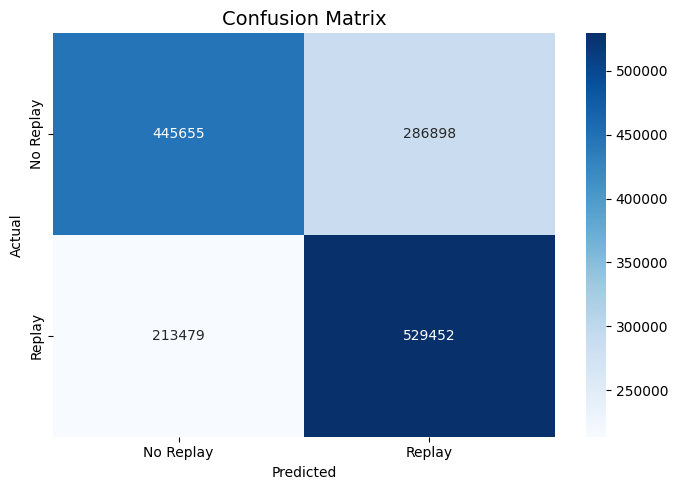

   Saved: confusion_matrix.png


In [64]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Replay', 'Replay'],
            yticklabels=['No Replay', 'Replay'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Saved: confusion_matrix.png')

## 13. Feature Importance

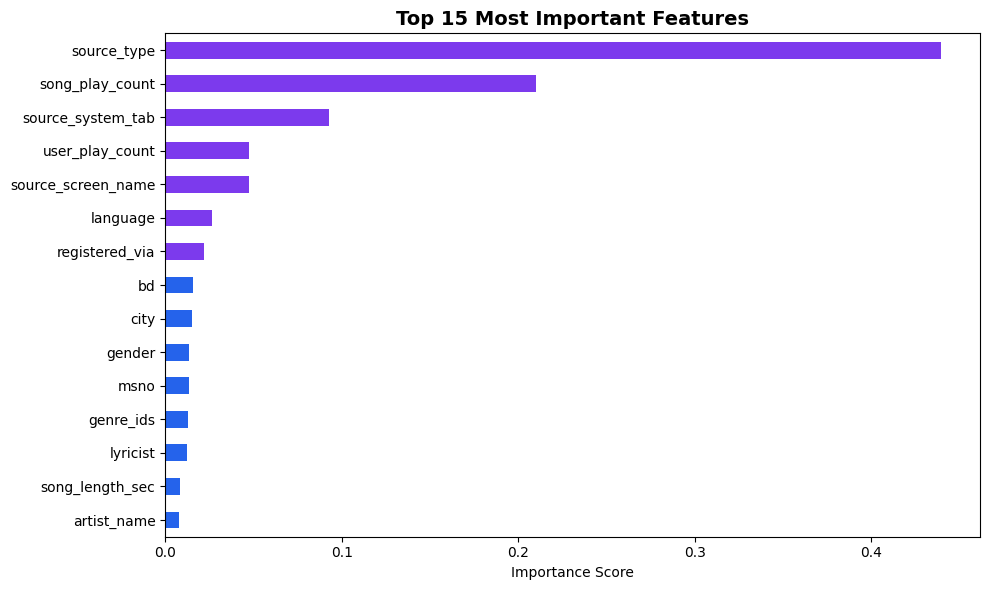

   Saved: feature_importance.png

Top 10 Features:
source_type           0.439555
song_play_count       0.210271
source_system_tab     0.092614
user_play_count       0.047733
source_screen_name    0.047446
language              0.026696
registered_via        0.022081
bd                    0.015705
city                  0.015388
gender                0.013590


In [65]:
feat_importance = pd.Series(model.feature_importances_, index=feature_cols)
top_features    = feat_importance.nlargest(15).sort_values()

plt.figure(figsize=(10, 6))
colors = ['#7c3aed' if v > top_features.median() else '#2563eb' for v in top_features]
top_features.plot(kind='barh', color=colors, edgecolor='none')
plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('   Saved: feature_importance.png')

print('\nTop 10 Features:')
print(feat_importance.nlargest(10).to_string())

## 14. Generating Music

In [66]:
def get_recommendations(user_id, df, model, feature_cols, top_n=10):
    """
    Generate top N song recommendations for a given user.
    
    Parameters:
        user_id      : encoded user ID (msno)
        df           : merged dataframe
        model        : trained XGBoost model
        feature_cols : list of feature column names
        top_n        : number of recommendations to return
    
    Returns:
        DataFrame with song_id and replay_probability
    """
    # Get songs this user already played
    user_songs   = df[df['msno'] == user_id]['song_id'].unique()
    all_songs    = df['song_id'].unique()
    unseen_songs = [s for s in all_songs if s not in user_songs]

    if not unseen_songs:
        print(f'   User {user_id} has already played all songs!')
        return pd.DataFrame()

    # Get a sample of unseen songs
    sample = df[df['song_id'].isin(unseen_songs[:1000])].drop_duplicates('song_id').copy()

    # Apply user-level features to the candidate songs
    user_data = df[df['msno'] == user_id]
    if not user_data.empty:
        sample['msno']             = user_id
        sample['user_play_count']  = user_data['user_play_count'].values[0]
        sample['user_replay_rate'] = user_data['user_replay_rate'].values[0]

    # Predict replay probability
    X_sample = sample[feature_cols].fillna(0)
    probs    = model.predict_proba(X_sample)[:, 1]
    sample   = sample.copy()
    sample['replay_probability'] = probs

    # Return top N sorted by probability
    result = sample[['song_id', 'replay_probability', 'song_play_count', 'song_replay_rate']]\
                   .sort_values('replay_probability', ascending=False)\
                   .head(top_n)\
                   .reset_index(drop=True)
    result.index += 1  # start ranking from 1
    return result

print(' Recommendation function defined!')

 Recommendation function defined!


In [67]:
# Generate recommendations for a sample user
sample_user = df['msno'].iloc[0]

print(f' Generating Top 10 Recommendations for User: {sample_user}')
print('=' * 55)

recommendations = get_recommendations(sample_user, df, model, feature_cols, top_n=10)

if not recommendations.empty:
    print(recommendations.to_string())
    print('\n✅ Recommendations generated successfully!')

🎵 Generating Top 10 Recommendations for User: 8158
    song_id  replay_probability  song_play_count  song_replay_rate
1    194341            0.864911             2950          0.546102
2    190019            0.846292             3869          0.669424
3     81838            0.845263             3127          0.607611
4    351179            0.832794             3562          0.595171
5    293813            0.832605             3347          0.579922
6     42176            0.827117             3046          0.586671
7    112794            0.818626             3393          0.601238
8    237639            0.818528             1409          0.601136
9     19099            0.815963             2034          0.613078
10   160980            0.807985             1813          0.616106

✅ Recommendations generated successfully!


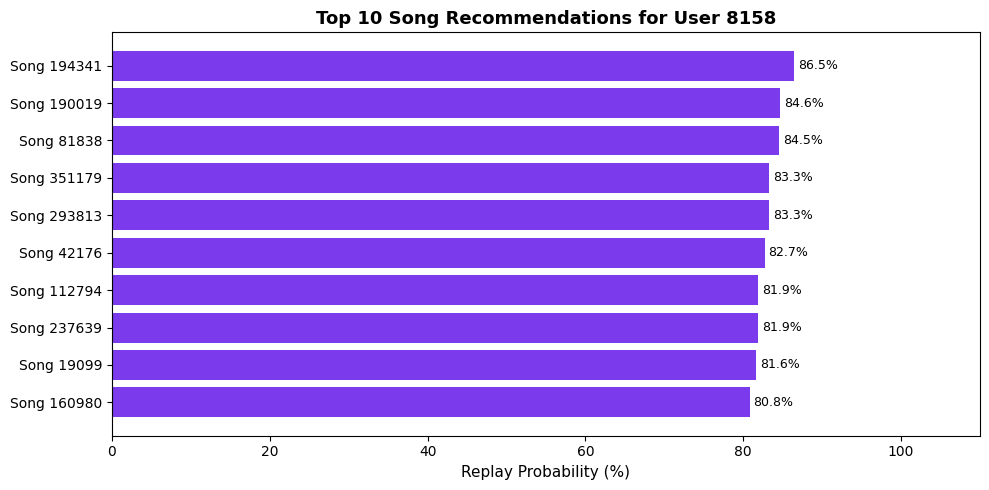

   Saved: recommendations.png


In [68]:
# Visualize recommendations
if not recommendations.empty:
    plt.figure(figsize=(10, 5))
    labels = [f'Song {sid}' for sid in recommendations['song_id']]
    probs  = recommendations['replay_probability'] * 100
    colors = ['#7c3aed' if p > 80 else '#2563eb' for p in probs]

    bars = plt.barh(labels[::-1], probs[::-1], color=colors[::-1], edgecolor='none')
    plt.xlabel('Replay Probability (%)', fontsize=11)
    plt.title(f'Top 10 Song Recommendations for User {sample_user}', fontsize=13, fontweight='bold')

    # Add percentage labels on bars
    for bar, prob in zip(bars, probs[::-1]):
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{prob:.1f}%', va='center', fontsize=9)

    plt.xlim(0, 110)
    plt.tight_layout()
    plt.savefig('recommendations.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('   Saved: recommendations.png')

## 15. Saving Model

In [69]:
with open('music_recommendation_model.pkl', 'wb') as f:
    pickle.dump(model, f)

import json
with open('feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print(' Saved: music_recommendation_model.pkl')
print(' Saved: feature_cols.json')
print('\n PROJECT COMPLETE!')


 Saved: music_recommendation_model.pkl
 Saved: feature_cols.json

 PROJECT COMPLETE!


In [70]:
---
##  Project Summary

| Step | Description | Status |
|------|-------------|--------|
| 1 | Install & Import Libraries | ✅ |
| 2 | Load KKBOX Dataset | ✅ |
| 3 | Exploratory Data Analysis | ✅ |
| 4 | Merge Datasets | ✅ |
| 5 | Data Cleaning | ✅ |
| 6 | Feature Engineering | ✅ |
| 7 | Encode Categorical Columns | ✅ |
| 8 | Select Features & Target | ✅ |
| 9 | Train / Test Split (80/20) | ✅ |
| 10 | Train XGBoost Model | ✅ |
| 11 | Evaluate (Accuracy + AUC-ROC) | ✅ |
| 12 | Feature Importance Plot | ✅ |
| 13 | Generate Recommendations | ✅ |
| 14 | Save Model | ✅ |

---

**Built by:** MINAHIL AFTAB
**Company:** Rhombix Technologies  
**Domain:** Machine Learning  
**Task:** Month 1 — Music Recommendation System  
**Algorithm:** XGBoost Classifier  
**Dataset:** KKBOX Music Recommendation Challenge (Kaggle)

SyntaxError: invalid character '✅' (U+2705) (3400813037.py, line 6)